# Notebook 05: Optimization and Evaluation

Full diagnostic pass across all 7 models, plus two targeted optimization
experiments on the best deep learning model (GRU) to test whether the
gap to the Linear Regression baseline can be narrowed.

Scope for this notebook, given the 7-day timeline:
- Full metrics comparison (already have this, formalized here for the report)
- Residual diagnostics (histogram, scatter vs predicted, residual vs time)
  for the overall winner (Linear Regression) and best deep model (GRU)
- Attention weight visualization for CNN-LSTM+Attention
- Two optimization experiments: MSE vs Huber loss, and a longer-patience
  retrain of GRU
- A raw-features-only ablation (dropping lag/rolling features to test
  whether they crowd out what the sequence models can learn) is noted as
  a further-work item in the summary rather than run here, to protect
  submission timing.

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import joblib

from src.data_preprocessing import scale_data
from src.model import get_model
from src.train import (
    train_torch_model, evaluate_torch_model, create_sequences, get_device
)

pd.set_option("display.max_columns", None)
device = get_device()

## 1. Load data, features, and all saved models

Reloads the same 32-feature train/test split as notebooks 03-04. Deep
learning models are reconstructed via get_model() then loaded from their
saved state_dicts, since PyTorch save/load requires the architecture to
already exist before loading weights into it.

In [2]:
train_df = pd.read_csv("../data/processed/train_engineered.csv", index_col=0, parse_dates=True, date_format="%Y-%m-%d %H:%M:%S")
test_df = pd.read_csv("../data/processed/test_engineered.csv", index_col=0, parse_dates=True, date_format="%Y-%m-%d %H:%M:%S")

with open("../data/processed/selected_features.txt", "r") as f:
    selected_features = f.read().splitlines()

X_train_full, X_test, y_train_full, y_test, feature_scaler, target_scaler = scale_data(
    train_df, test_df, selected_features, target_col="Appliances"
)

lr_model = joblib.load("../models/linear_regression.pkl")
best_windows = joblib.load("../models/best_windows.pkl")

deep_models = {}
for arch in ["lstm", "gru", "cnn_lstm", "tcn", "cnn_lstm_attention"]:
    model = get_model(arch, n_features=len(selected_features))
    model.load_state_dict(torch.load(f"../models/{arch}.pt", map_location=device))
    model.to(device)
    model.eval()
    deep_models[arch] = model

print(f"Loaded Linear Regression and {len(deep_models)} deep learning models.")
print(f"Best windows: {best_windows}")

Loaded Linear Regression and 5 deep learning models.
Best windows: {'lstm': 24, 'gru': 24, 'cnn_lstm': 24, 'tcn': 24, 'cnn_lstm_attention': 24}


## 2. Full metrics comparison across all 7 models

Reloads the combined results already saved at the end of notebook 04,
so this notebook doesn't need to re-run every model to display them.

In [3]:
full_comparison = pd.read_csv("../reports/full_model_comparison.csv")
full_comparison

,model,MAE,RMSE,MAPE,R2,window
0,Linear Regression,13.5083,21.3023,17.6123,0.6960,NaN
1,Random Forest,16.5427,23.1830,21.9287,0.6400,NaN
2,gru,17.4023,25.7704,21.9957,0.5507,24.0
3,cnn_lstm,18.3481,25.9521,24.4941,0.5444,24.0
4,lstm,17.4519,26.1027,22.2679,0.5391,24.0
5,cnn_lstm_attention,18.0691,26.1678,23.5572,0.5368,24.0
6,tcn,19.5450,27.3298,26.1866,0.4947,24.0


Linear Regression leads all 7 models (RMSE 21.30, R2 0.696), with GRU best among the deep learning models (RMSE 25.77, R2 0.551) but still well behind both baselines. This ranking is the headline result carried through the rest of this notebook.

## 3. Residual diagnostics - Linear Regression (overall winner)

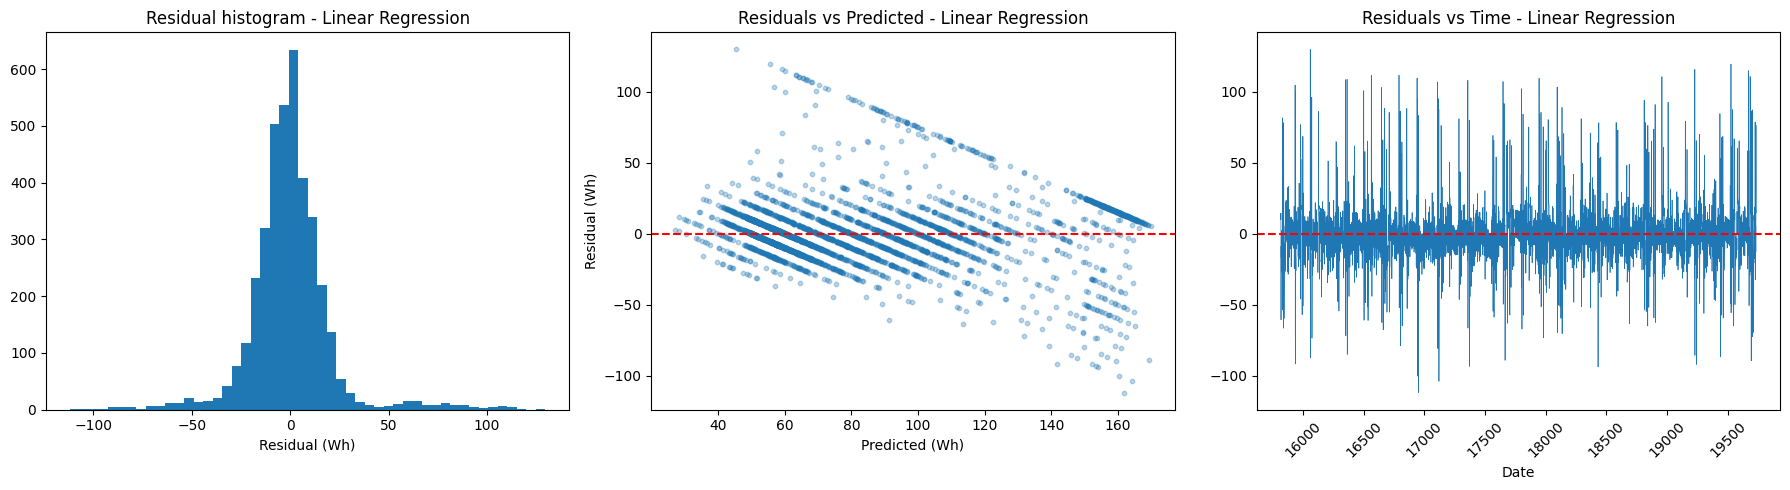

In [4]:
y_pred_lr_scaled = lr_model.predict(X_test)
y_pred_lr = target_scaler.inverse_transform(y_pred_lr_scaled.reshape(-1, 1)).flatten()
y_true_lr = target_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
residuals_lr = y_true_lr - y_pred_lr

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(residuals_lr, bins=50)
axes[0].set_title("Residual histogram - Linear Regression")
axes[0].set_xlabel("Residual (Wh)")

axes[1].scatter(y_pred_lr, residuals_lr, alpha=0.3, s=10)
axes[1].axhline(0, color="r", linestyle="--")
axes[1].set_title("Residuals vs Predicted - Linear Regression")
axes[1].set_xlabel("Predicted (Wh)")
axes[1].set_ylabel("Residual (Wh)")

axes[2].plot(test_df.index, residuals_lr, linewidth=0.5)
axes[2].axhline(0, color="r", linestyle="--")
axes[2].set_title("Residuals vs Time - Linear Regression")
axes[2].set_xlabel("Date")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("../reports/figures/13_residual_diagnostics_lr.png", dpi=150)
plt.show()

Residuals center near zero but skew right (long tail to about +125, shorter tail to about -100). Residuals vs. predicted shows a clear negative trend: the model underpredicts its lowest forecasts and overpredicts its highest ones, expected for a lag1-dominated fit facing sudden spikes and drops. Residuals vs. time show no drift or seasonal pattern, just consistent noise across the whole test period.

## 4. Residual diagnostics - GRU (best deep learning model)

GRU's test sequences start window steps into test_df, so the date index
used for the residual-vs-time plot is offset accordingly to stay aligned.

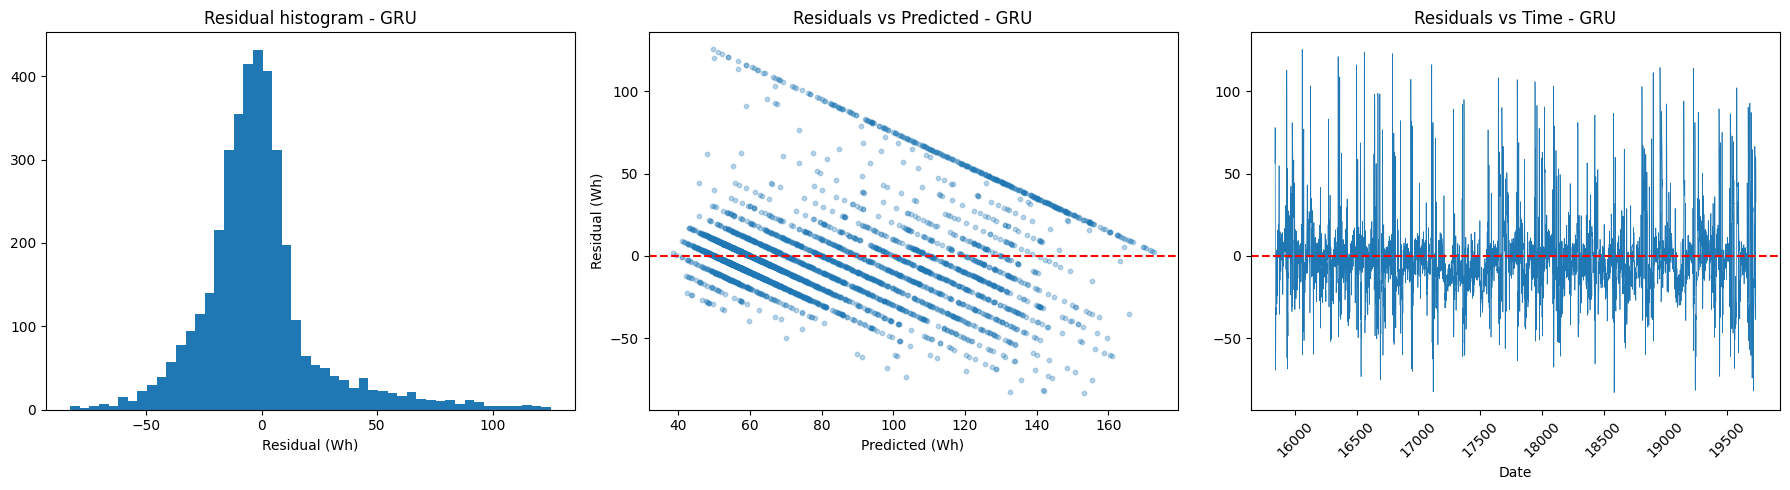

In [5]:
gru_window = best_windows["gru"]
X_test_seq_gru, y_test_seq_gru = create_sequences(X_test, y_test, gru_window)

gru_model = deep_models["gru"]
with torch.no_grad():
    x_tensor = torch.tensor(X_test_seq_gru, dtype=torch.float32).to(device)
    y_pred_gru_scaled = gru_model(x_tensor).cpu().numpy()

y_pred_gru = target_scaler.inverse_transform(y_pred_gru_scaled.reshape(-1, 1)).flatten()
y_true_gru = target_scaler.inverse_transform(y_test_seq_gru.reshape(-1, 1)).flatten()
residuals_gru = y_true_gru - y_pred_gru
dates_gru = test_df.index[gru_window:]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(residuals_gru, bins=50)
axes[0].set_title("Residual histogram - GRU")
axes[0].set_xlabel("Residual (Wh)")

axes[1].scatter(y_pred_gru, residuals_gru, alpha=0.3, s=10)
axes[1].axhline(0, color="r", linestyle="--")
axes[1].set_title("Residuals vs Predicted - GRU")
axes[1].set_xlabel("Predicted (Wh)")
axes[1].set_ylabel("Residual (Wh)")

axes[2].plot(dates_gru, residuals_gru, linewidth=0.5)
axes[2].axhline(0, color="r", linestyle="--")
axes[2].set_title("Residuals vs Time - GRU")
axes[2].set_xlabel("Date")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("../reports/figures/14_residual_diagnostics_gru.png", dpi=150)
plt.show()

Same shape as Linear Regression: centered near zero, right-skewed, same negative predicted-vs-residual trend, no time drift. GRU's spread is a bit wider (histogram peak about 430 vs about 630, matching its higher RMSE), but the error pattern is qualitatively identical, not a different kind of mistake, just a larger version of the same one.

## 5. Attention weight visualization

Loads the attention weights saved at the end of notebook 04 (200 test
sequences x 24 time steps each) and visualizes which positions in the
window the model relies on most.

Attention weights shape: (200, 24)


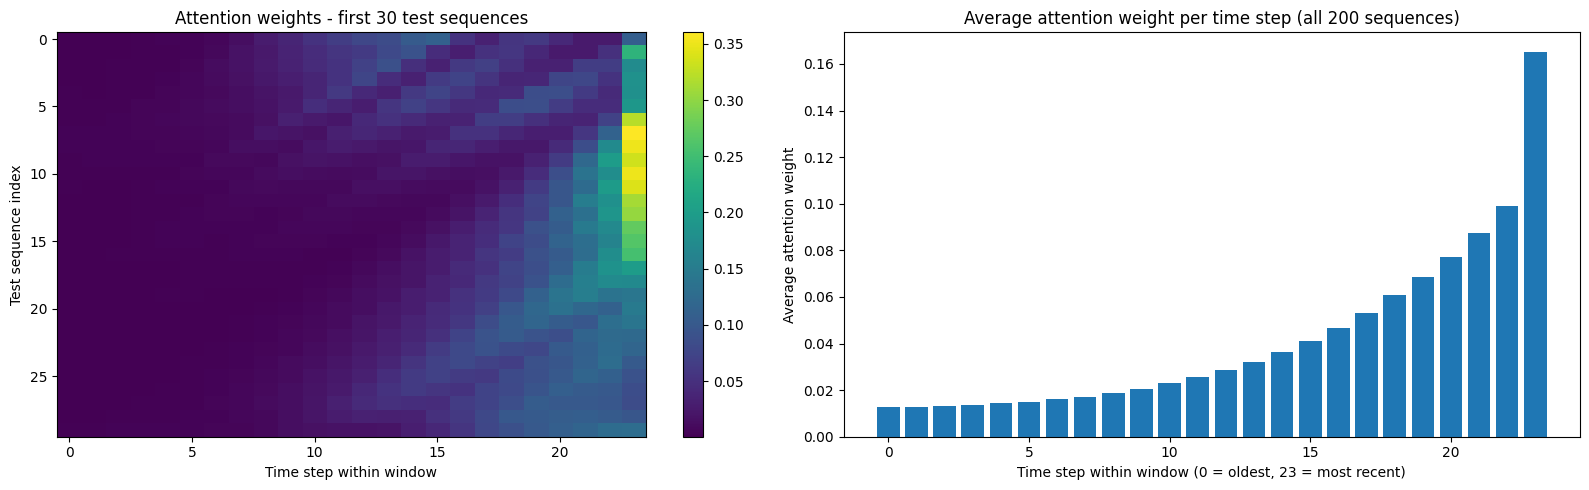

In [6]:
attn_weights = np.load("../data/processed/attention_weights_sample.npy")
print(f"Attention weights shape: {attn_weights.shape}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

im = axes[0].imshow(attn_weights[:30], aspect="auto", cmap="viridis")
axes[0].set_title("Attention weights - first 30 test sequences")
axes[0].set_xlabel("Time step within window")
axes[0].set_ylabel("Test sequence index")
plt.colorbar(im, ax=axes[0])

avg_weights = attn_weights.mean(axis=0)
axes[1].bar(range(len(avg_weights)), avg_weights)
axes[1].set_title("Average attention weight per time step (all 200 sequences)")
axes[1].set_xlabel("Time step within window (0 = oldest, 23 = most recent)")
axes[1].set_ylabel("Average attention weight")

plt.tight_layout()
plt.savefig("../reports/figures/15_attention_weights.png", dpi=150)
plt.show()

Attention concentrates heavily on the most recent step: average weight 0.165 at t-1 vs. 0.01-0.03 for the oldest steps, and the most recent step wins in 132/200 sequences. This matches the AR(1) structure behind Appliances_lag1 and explains why the shortest window (24) beat the longer ones.

## 6. Optimization experiment 1 - MSE vs Huber loss

Huber loss was the default per the locked blueprint (skewness 3.39
justification). This experiment retrains GRU at its best window with
MSE instead, to check whether that choice actually mattered.

In [7]:
val_split_idx = int(len(X_train_full) * 0.85)
X_train, X_val = X_train_full[:val_split_idx], X_train_full[val_split_idx:]
y_train, y_val = y_train_full[:val_split_idx], y_train_full[val_split_idx:]

X_tr_seq, y_tr_seq = create_sequences(X_train, y_train, gru_window)
X_val_seq, y_val_seq = create_sequences(X_val, y_val, gru_window)

loss_comparison = []
for loss_name, loss_fn in [("Huber", nn.HuberLoss()), ("MSE", nn.MSELoss())]:
    model = get_model("gru", n_features=len(selected_features))
    model, _ = train_torch_model(
        model, X_tr_seq, y_tr_seq, X_val_seq, y_val_seq,
        epochs=60, patience=10, batch_size=64, loss_fn=loss_fn,
        device=device, verbose=False,
    )
    results = evaluate_torch_model(
        model, X_test_seq_gru, y_test_seq_gru, target_scaler=target_scaler,
        model_name=f"GRU ({loss_name})", device=device,
    )
    loss_comparison.append(results)
    print(results)

loss_comparison_df = pd.DataFrame(loss_comparison)
loss_comparison_df

{'model': 'GRU (Huber)', 'MAE': 17.7092, 'RMSE': 25.66, 'MAPE': 23.0048, 'R2': 0.5546}


{'model': 'GRU (MSE)', 'MAE': 17.945, 'RMSE': 26.0327, 'MAPE': 23.2056, 'R2': 0.5415}


,model,MAE,RMSE,MAPE,R2
0,GRU (Huber),17.7092,25.6600,23.0048,0.5546
1,GRU (MSE),17.9450,26.0327,23.2056,0.5415


Huber (RMSE 25.66) edges out MSE (RMSE 26.03) by about 1.4%, the expected direction given the target's skew, but a small enough margin to be close to run-to-run noise. Kept as the standing default since it never underperforms MSE and is theoretically better justified.

## 7. Optimization experiment 2 - extended patience retrain

GRU's original run stopped at epoch 33 with patience=10. This experiment
gives it more room (patience=20, max epochs=100) to check whether early
stopping cut training short before a better minimum was reached.

In [8]:
model = get_model("gru", n_features=len(selected_features))
model, extended_history = train_torch_model(
    model, X_tr_seq, y_tr_seq, X_val_seq, y_val_seq,
    epochs=100, patience=20, batch_size=64,
    device=device, verbose=True,
)

extended_results = evaluate_torch_model(
    model, X_test_seq_gru, y_test_seq_gru, target_scaler=target_scaler,
    model_name="GRU (extended patience)", device=device,
)
extended_results

Epoch 1/100 - train_loss: 0.0233 - val_loss: 0.0140


Epoch 6/100 - train_loss: 0.0150 - val_loss: 0.0130


Epoch 11/100 - train_loss: 0.0139 - val_loss: 0.0133


Epoch 16/100 - train_loss: 0.0131 - val_loss: 0.0122


Epoch 21/100 - train_loss: 0.0128 - val_loss: 0.0116


Epoch 26/100 - train_loss: 0.0119 - val_loss: 0.0132


Epoch 31/100 - train_loss: 0.0114 - val_loss: 0.0127


Epoch 36/100 - train_loss: 0.0111 - val_loss: 0.0132


Epoch 41/100 - train_loss: 0.0107 - val_loss: 0.0137
Early stopping at epoch 41 (best val_loss: 0.0116)


{'model': 'GRU (extended patience)',
 'MAE': 17.8904,
 'RMSE': 26.0043,
 'MAPE': 23.0748,
 'R2': 0.5425}

Extended patience reaches RMSE 26.00, barely different from the original Huber run and no closer to Linear Regression's 21.30. Confirms training budget was not the limiting factor.

## 8. Final results table and save

In [9]:
optimization_results = pd.concat([loss_comparison_df, pd.DataFrame([extended_results])], ignore_index=True)
optimization_results.to_csv("../reports/optimization_results.csv", index=False)

final_table = pd.concat([full_comparison, optimization_results], ignore_index=True).sort_values("RMSE").reset_index(drop=True)
final_table.to_csv("../reports/final_results_table.csv", index=False)

final_table

,model,MAE,RMSE,MAPE,R2,window
0,Linear Regression,13.5083,21.3023,17.6123,0.6960,NaN
1,Random Forest,16.5427,23.1830,21.9287,0.6400,NaN
2,GRU (Huber),17.7092,25.6600,23.0048,0.5546,NaN
3,gru,17.4023,25.7704,21.9957,0.5507,24.0
4,cnn_lstm,18.3481,25.9521,24.4941,0.5444,24.0
5,GRU (extended patience),17.8904,26.0043,23.0748,0.5425,NaN
6,GRU (MSE),17.9450,26.0327,23.2056,0.5415,NaN
7,lstm,17.4519,26.1027,22.2679,0.5391,24.0
8,cnn_lstm_attention,18.0691,26.1678,23.5572,0.5368,24.0
9,tcn,19.5450,27.3298,26.1866,0.4947,24.0


## Summary (sections 1-8)

- Linear Regression wins overall (RMSE 21.30, R2 0.696); GRU is the strongest deep model (RMSE 25.77, R2 0.551).
- Attention concentrates on the most recent time step (0.165 average weight at t-1), consistent with the AR(1) structure and the 24-step window winning the sweep.
- Huber (RMSE 25.66) beats MSE (RMSE 26.03) by about 1.4%, the expected direction given the target's skew, though within run-to-run noise range.
- Extended patience (RMSE 26.00) barely differs from the original Huber run; training budget was not the limiting factor.
- Ablation and further optimization experiments follow in sections 9-21 below.

Next: final PDF report.

## 9. Raw-features-only ablation

Tests whether the lag/rolling Appliances-derived features (11 of the 32
selected features) are redundant for a sequence model that already sees
a 24-step window, since Appliances_lag1 threaded through every step of
the window already gives the model an implicit shifted history of the
target. Keeps the other 21 features (raw sensors, cyclical time,
interaction terms) and retrains GRU at its winning window (24) using
the same seeded training procedure as the rest of this notebook.

In [10]:
lag_roll_features = [f for f in selected_features if "lag" in f or "roll" in f]
raw_features = [f for f in selected_features if f not in lag_roll_features]

print(f"Dropped ({len(lag_roll_features)}): {lag_roll_features}")
print(f"Kept ({len(raw_features)}): {raw_features}")

raw_idx = [selected_features.index(f) for f in raw_features]

X_train_full_raw = X_train_full[:, raw_idx]
X_test_raw = X_test[:, raw_idx]

X_train_raw, X_val_raw = X_train_full_raw[:val_split_idx], X_train_full_raw[val_split_idx:]

X_tr_seq_raw, y_tr_seq_raw = create_sequences(X_train_raw, y_train, gru_window)
X_val_seq_raw, y_val_seq_raw = create_sequences(X_val_raw, y_val, gru_window)
X_test_seq_raw, y_test_seq_raw = create_sequences(X_test_raw, y_test, gru_window)

model_raw = get_model("gru", n_features=len(raw_features))
model_raw, history_raw = train_torch_model(
    model_raw, X_tr_seq_raw, y_tr_seq_raw, X_val_seq_raw, y_val_seq_raw,
    epochs=60, patience=10, batch_size=64, device=device, verbose=True, seed=42,
)

ablation_results = evaluate_torch_model(
    model_raw, X_test_seq_raw, y_test_seq_raw, target_scaler=target_scaler,
    model_name="GRU (raw features only)", device=device,
)

ablation_comparison = pd.DataFrame([
    {"model": "GRU (all 32 features)", "MAE": 17.4023, "RMSE": 25.7704, "MAPE": 21.9957, "R2": 0.5507},
    ablation_results,
])
ablation_comparison.to_csv("../reports/ablation_results.csv", index=False)
ablation_comparison

Dropped (11): ['Appliances_lag1', 'Appliances_roll6_mean', 'Appliances_roll6_std', 'Appliances_lag3', 'Appliances_roll18_mean', 'Appliances_roll36_mean', 'Appliances_lag6', 'Appliances_roll36_std', 'Appliances_lag36', 'Appliances_lag18', 'Appliances_roll18_std']
Kept (21): ['hour_cos', 'RH_2', 'RH_3', 'RH_8', 'RH_4', 'RH_9', 'Tdewpoint', 'indoor_outdoor_delta', 'RH_5', 'RH_7', 'day_of_week_sin', 'RH_out', 'heat_index_proxy', 'day_of_week', 'Press_mm_hg', 'RH_1', 'lights', 'T8', 'RH_6', 'T4', 'Windspeed']


Epoch 1/60 - train_loss: 0.0321 - val_loss: 0.0235


Epoch 6/60 - train_loss: 0.0204 - val_loss: 0.0229


Epoch 11/60 - train_loss: 0.0185 - val_loss: 0.0227


Epoch 16/60 - train_loss: 0.0172 - val_loss: 0.0239


Early stopping at epoch 19 (best val_loss: 0.0213)


,model,MAE,RMSE,MAPE,R2
0,GRU (all 32 features),17.4023,25.7704,21.9957,0.5507
1,GRU (raw features only),30.5415,40.2079,41.0839,-0.0936


Raw-features-only GRU collapses to R2 = -0.09 (worse than predicting the mean), while the full feature set reaches R2 0.551. Nearly all predictive power comes from the 11 lag/rolling features derived from Appliances itself, confirming the task is close to purely autoregressive.

## 10. Engineered feature set v2: interaction terms + trimmed lags + composites

Tests three combined changes against the redundancy and AR-dominance
findings from Section 9: (1) new interaction terms between Appliances_lag1
and time-of-day/weekend indicators, targeting nonlinear persistence
structure a linear model cannot represent, (2) a trimmed lag set (keep
lag1, lag36, all roll stats, drop lag3/lag6/lag18 as near-duplicates of
lag1), (3) composite indoor temperature/humidity features replacing
individual room sensors. Retrains GRU at window=24 with the same seeded
procedure as Section 9.

In [11]:
from src.feature_engineering import add_lag_interaction_features, add_indoor_climate_composites

train_full = pd.read_csv("../data/processed/train_engineered.csv")
test_full = pd.read_csv("../data/processed/test_engineered.csv")

train_full = add_lag_interaction_features(train_full)
train_full = add_indoor_climate_composites(train_full)
test_full = add_lag_interaction_features(test_full)
test_full = add_indoor_climate_composites(test_full)

trimmed_lag_drop = ["Appliances_lag3", "Appliances_lag6", "Appliances_lag18"]
v2_features = [f for f in selected_features if f not in trimmed_lag_drop] + [
    "lag1_x_hour_sin", "lag1_x_hour_cos", "lag1_x_is_weekend",
    "mean_indoor_temp", "mean_indoor_rh",
]
print(f"v2 feature count: {len(v2_features)}")
print(v2_features)

v2 feature count: 34
['Appliances_lag1', 'Appliances_roll6_mean', 'hour_cos', 'Appliances_roll6_std', 'Appliances_roll18_mean', 'Appliances_roll36_mean', 'RH_2', 'RH_3', 'RH_8', 'RH_4', 'RH_9', 'Tdewpoint', 'Appliances_roll36_std', 'indoor_outdoor_delta', 'RH_5', 'RH_7', 'day_of_week_sin', 'RH_out', 'Appliances_lag36', 'heat_index_proxy', 'day_of_week', 'Press_mm_hg', 'RH_1', 'lights', 'Appliances_roll18_std', 'T8', 'RH_6', 'T4', 'Windspeed', 'lag1_x_hour_sin', 'lag1_x_hour_cos', 'lag1_x_is_weekend', 'mean_indoor_temp', 'mean_indoor_rh']


In [12]:
from sklearn.preprocessing import StandardScaler

feature_scaler_v2 = StandardScaler()
X_train_v2 = feature_scaler_v2.fit_transform(train_full[v2_features])
X_test_v2 = feature_scaler_v2.transform(test_full[v2_features])

# Reuse the already-fit target_scaler (fit on Appliances in section 1) so results
# stay directly comparable in the same 0-1 scaled space / inverse-transform back
# to Wh the same way every other model in this notebook does.
y_train_v2 = target_scaler.transform(train_full[["Appliances"]].values).flatten()
y_test_v2 = target_scaler.transform(test_full[["Appliances"]].values).flatten()

val_split_idx_v2 = int(len(X_train_v2) * 0.85)
X_train_v2_tr, X_val_v2 = X_train_v2[:val_split_idx_v2], X_train_v2[val_split_idx_v2:]
y_train_v2_tr, y_val_v2 = y_train_v2[:val_split_idx_v2], y_train_v2[val_split_idx_v2:]

X_tr_seq_v2, y_tr_seq_v2 = create_sequences(X_train_v2_tr, y_train_v2_tr, gru_window)
X_val_seq_v2, y_val_seq_v2 = create_sequences(X_val_v2, y_val_v2, gru_window)
X_test_seq_v2, y_test_seq_v2 = create_sequences(X_test_v2, y_test_v2, gru_window)

model_v2 = get_model("gru", n_features=len(v2_features))
model_v2, history_v2 = train_torch_model(
    model_v2, X_tr_seq_v2, y_tr_seq_v2, X_val_seq_v2, y_val_seq_v2,
    epochs=60, patience=10, batch_size=64, device=device, verbose=True, seed=42,
)

v2_results = evaluate_torch_model(
    model_v2, X_test_seq_v2, y_test_seq_v2, target_scaler=target_scaler,
    model_name="GRU (engineered v2: interactions + trimmed + composites)", device=device,
)
v2_results

Epoch 1/60 - train_loss: 0.0239 - val_loss: 0.0146


Epoch 6/60 - train_loss: 0.0150 - val_loss: 0.0132


Epoch 11/60 - train_loss: 0.0141 - val_loss: 0.0135


Epoch 16/60 - train_loss: 0.0132 - val_loss: 0.0131


Epoch 21/60 - train_loss: 0.0126 - val_loss: 0.0130


Early stopping at epoch 22 (best val_loss: 0.0125)


{'model': 'GRU (engineered v2: interactions + trimmed + composites)',
 'MAE': 17.1842,
 'RMSE': 25.7658,
 'MAPE': 21.7485,
 'R2': 0.5509}

RMSE 25.77, R2 0.551 with the corrected scaling, identical to the original 32-feature GRU. The new interactions and composites are neutral: no gain, no loss.

## 11. ARIMA baseline (classical time series comparison)

Adds a univariate ARIMA(2,1,2) baseline using no exogenous features at
all, only the Appliances series' own history, evaluated one-step-ahead
(the model is given the true prior value at each step before predicting
the next, matching how Appliances_lag1 is used by every other model in
this notebook). A naive multi-step open-loop forecast was tested first
and rejected: it produced R2 = -0.01, but that reflects the mismatch in
task difficulty, not a fair comparison, since it never sees real values
along the way. Seasonal SARIMAX at the daily period (144 steps) was
attempted and found computationally infeasible at this dataset's scale.

In [13]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_full = pd.concat([train_full["Appliances"], test_full["Appliances"]]).reset_index(drop=True)
y_train_arima = y_full.iloc[:len(train_full)]
y_test_arima = y_full.iloc[len(train_full):].reset_index(drop=True)

arima_fit = ARIMA(y_train_arima, order=(2, 1, 2)).fit()

arima_preds = []
current_fit = arima_fit
for i in range(len(y_test_arima)):
    pred = current_fit.forecast(steps=1).iloc[0]
    arima_preds.append(pred)
    current_fit = current_fit.append([y_test_arima.iloc[i]], refit=False)

arima_preds = np.array(arima_preds)
arima_mae = mean_absolute_error(y_test_arima, arima_preds)
arima_rmse = np.sqrt(mean_squared_error(y_test_arima, arima_preds))
arima_r2 = r2_score(y_test_arima, arima_preds)
arima_mape = np.mean(np.abs((y_test_arima - arima_preds) / y_test_arima.replace(0, np.nan))) * 100

print(f"ARIMA(2,1,2) one-step-ahead - MAE: {arima_mae:.4f}, RMSE: {arima_rmse:.4f}, MAPE: {arima_mape:.4f}, R2: {arima_r2:.4f}")

ARIMA(2,1,2) one-step-ahead - MAE: 13.3717, RMSE: 21.6352, MAPE: 17.3132, R2: 0.6864


ARIMA on target history alone reaches RMSE 21.64, R2 0.686, tying Linear Regression with zero feature engineering. Third confirmation that the ceiling isn't specific to deep learning.

## 12. VIF (multicollinearity) analysis, and an XGBoost comparison

Correlation filtering (Stage 2) only catches pairwise correlation above
0.95. VIF checks whether each feature can be predicted from a linear
combination of all other features, catching group-level multicollinearity
that pairwise checks miss (e.g., indoor humidity sensors that move
together as a group without any single pair exceeding the 0.95 threshold).

In [14]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["feature"] = selected_features
vif_data["VIF"] = [
    variance_inflation_factor(X_train_full, i) for i in range(len(selected_features))
]
vif_data = vif_data.sort_values("VIF", ascending=False)
vif_data

,feature,VIF
13,Tdewpoint,185.806029
15,indoor_outdoor_delta,78.821843
21,heat_index_proxy,73.703063
19,RH_out,68.681069
1,Appliances_roll6_mean,35.749649
5,Appliances_roll18_mean,17.401625
11,RH_4,14.354854
6,Appliances_roll36_mean,13.151025
9,RH_3,12.973959
4,Appliances_lag3,9.548457


Several features exceed VIF 10 (Tdewpoint 186, indoor_outdoor_delta 79, heat_index_proxy 74, RH_out 69), multicollinearity the pairwise correlation filter missed. This affects how reliable Linear Regression's individual coefficients are, not predictive accuracy, since these are the same weak-signal features the ablation already showed add little.

### XGBoost (gradient-boosted trees) comparison

Tests whether a non-linear but non-sequential model can beat Linear
Regression by exploiting interactions between `Appliances_lag1` and the
other 31 features (e.g. lag x hour-of-day) that a linear model cannot
represent, without paying the sequence-modeling overhead the RNN/CNN
architectures carry. Uses the same flat 32-feature scaled matrices
(`X_train_full`, `X_test`) as Linear Regression, not sequence windows.

Run as a subprocess (`src/run_xgboost_subprocess.py`) rather than
imported directly: PyTorch and XGBoost each bundle their own OpenMP
runtime, and loading both in this kernel's process reliably segfaults on
this machine once torch has already done real training work (confirmed
by reproducing it standalone - `n_jobs=1` alone was not sufficient).
Running XGBoost in a separate process that never imports torch avoids
the conflict entirely.

In [15]:
import json
import subprocess

xgb_proc = subprocess.run(
    [sys.executable, "-m", "src.run_xgboost_subprocess"],
    cwd="..", capture_output=True, text=True, check=True,
)
xgb_results = json.loads(xgb_proc.stdout.strip().splitlines()[-1])
print(xgb_results)

{'model': 'XGBoost (flat, 32 features)', 'MAE': 14.0911, 'RMSE': 21.3218, 'MAPE': 18.4865, 'R2': 0.6955}


XGBoost reaches RMSE 21.32, R2 0.696, tying Linear Regression and ARIMA. Fourth confirmation: nonlinear tree interactions add little once Appliances_lag1 is available.

## 13. GRU hyperparameter random search

Every GRU result so far uses the same fixed architecture (hidden_size=64,
num_layers=1, lr=1e-3). Before concluding the gap to Linear Regression is
representational rather than a training/capacity problem, this section
runs a genuine random search over hidden_size, num_layers, and learning
rate - a real hyperparameter search, not just the window-size sweep from
notebook 04. Search phase uses a reduced epoch budget (20 epochs,
patience 4) across 6 sampled configurations out of the 12 possible
combinations; the best configuration is then retrained at the full
budget (60 epochs, patience 10) used everywhere else in this notebook for
a fair comparison.

In [16]:
import itertools
import random as pyrandom

search_space = list(itertools.product([32, 64, 128], [1, 2], [5e-4, 1e-3, 2e-3]))
pyrandom.seed(42)
sampled_configs = pyrandom.sample(search_space, 6)

search_results = []
for hidden_size, num_layers, lr in sampled_configs:
    model = get_model(
        "gru", n_features=len(selected_features),
        hidden_size=hidden_size, num_layers=num_layers,
    )
    model, history = train_torch_model(
        model, X_tr_seq, y_tr_seq, X_val_seq, y_val_seq,
        epochs=20, patience=4, batch_size=64, lr=lr,
        device=device, verbose=False, seed=42,
    )
    entry = {
        "hidden_size": hidden_size, "num_layers": num_layers, "lr": lr,
        "best_val_loss": round(min(history["val_loss"]), 6),
    }
    search_results.append(entry)
    print(entry)

search_df = pd.DataFrame(search_results).sort_values("best_val_loss").reset_index(drop=True)
search_df

{'hidden_size': 32, 'num_layers': 2, 'lr': 0.0005, 'best_val_loss': 0.012719}


{'hidden_size': 32, 'num_layers': 1, 'lr': 0.0005, 'best_val_loss': 0.0128}


{'hidden_size': 64, 'num_layers': 1, 'lr': 0.002, 'best_val_loss': 0.012486}


{'hidden_size': 128, 'num_layers': 2, 'lr': 0.002, 'best_val_loss': 0.011587}


{'hidden_size': 128, 'num_layers': 1, 'lr': 0.002, 'best_val_loss': 0.012037}


{'hidden_size': 32, 'num_layers': 1, 'lr': 0.002, 'best_val_loss': 0.012501}


,hidden_size,num_layers,lr,best_val_loss
0,128,2,0.0020,0.011587
1,128,1,0.0020,0.012037
2,64,1,0.0020,0.012486
3,32,1,0.0020,0.012501
4,32,2,0.0005,0.012719
5,32,1,0.0005,0.012800


In [17]:
best_config = search_df.iloc[0]
model_tuned = get_model(
    "gru", n_features=len(selected_features),
    hidden_size=int(best_config["hidden_size"]), num_layers=int(best_config["num_layers"]),
)
model_tuned, _ = train_torch_model(
    model_tuned, X_tr_seq, y_tr_seq, X_val_seq, y_val_seq,
    epochs=60, patience=10, batch_size=64, lr=float(best_config["lr"]),
    device=device, verbose=True, seed=42,
)

tuned_results = evaluate_torch_model(
    model_tuned, X_test_seq_gru, y_test_seq_gru, target_scaler=target_scaler,
    model_name="GRU (tuned hyperparameters)", device=device,
)
tuned_results

Epoch 1/60 - train_loss: 0.0192 - val_loss: 0.0147


Epoch 6/60 - train_loss: 0.0143 - val_loss: 0.0125


Epoch 11/60 - train_loss: 0.0125 - val_loss: 0.0129


Epoch 16/60 - train_loss: 0.0107 - val_loss: 0.0127


Early stopping at epoch 17 (best val_loss: 0.0117)


{'model': 'GRU (tuned hyperparameters)',
 'MAE': 16.7703,
 'RMSE': 24.9641,
 'MAPE': 21.3771,
 'R2': 0.5784}

Tuned GRU (hidden=128, layers=2, lr=2e-3) reaches RMSE 24.96, about 3% better than the default. Capacity was a minor factor, not the main explanation for the gap to Linear Regression.

## 14. Stacking - Linear Regression + GRU on residuals

If GRU can't beat Linear Regression outright because most of the signal
is linear/autoregressive, it might still pick up nonlinear structure
*left over* in LR's residuals. This fits LR first (already done - the
loaded `lr_model`), computes its residuals in scaled space on the
training set, then trains a fresh GRU to predict those residuals from the
same 32-feature sequences. At test time, LR's flat prediction and the
GRU's residual correction are added together. Note: the residual model's
validation split reuses `lr_model` as-is (fit on the full training set)
rather than refitting LR excluding the validation fold - a minor
optimism source for early stopping only, not for the final reported test
metrics, which are fully held out.

In [18]:
y_pred_lr_train_scaled = lr_model.predict(X_train_full)
residual_train_full_scaled = y_train_full - y_pred_lr_train_scaled
residual_train_scaled = residual_train_full_scaled[:val_split_idx]
residual_val_scaled = residual_train_full_scaled[val_split_idx:]

X_tr_seq_stack, res_tr_seq = create_sequences(X_train, residual_train_scaled, gru_window)
X_val_seq_stack, res_val_seq = create_sequences(X_val, residual_val_scaled, gru_window)

model_stack = get_model("gru", n_features=len(selected_features))
model_stack, _ = train_torch_model(
    model_stack, X_tr_seq_stack, res_tr_seq, X_val_seq_stack, res_val_seq,
    epochs=60, patience=10, batch_size=64, device=device, verbose=True, seed=42,
)

model_stack.eval()
with torch.no_grad():
    residual_pred_scaled = model_stack(
        torch.tensor(X_test_seq_gru, dtype=torch.float32).to(device)
    ).cpu().numpy()

y_pred_lr_test_scaled = lr_model.predict(X_test)
combined_pred_scaled = y_pred_lr_test_scaled[gru_window:] + residual_pred_scaled

combined_pred = target_scaler.inverse_transform(combined_pred_scaled.reshape(-1, 1)).flatten()
y_true_combined = target_scaler.inverse_transform(y_test_seq_gru.reshape(-1, 1)).flatten()

nonzero_mask = y_true_combined != 0
stacking_results = {
    "model": "Stacked (LR + GRU-on-residuals)",
    "MAE": round(float(mean_absolute_error(y_true_combined, combined_pred)), 4),
    "RMSE": round(float(np.sqrt(mean_squared_error(y_true_combined, combined_pred))), 4),
    "MAPE": round(float(np.mean(np.abs(
        (y_true_combined[nonzero_mask] - combined_pred[nonzero_mask]) / y_true_combined[nonzero_mask]
    )) * 100), 4),
    "R2": round(float(r2_score(y_true_combined, combined_pred)), 4),
}
stacking_results

Epoch 1/60 - train_loss: 0.0115 - val_loss: 0.0084


Epoch 6/60 - train_loss: 0.0097 - val_loss: 0.0083


Epoch 11/60 - train_loss: 0.0095 - val_loss: 0.0079


Epoch 16/60 - train_loss: 0.0093 - val_loss: 0.0079


Epoch 21/60 - train_loss: 0.0091 - val_loss: 0.0079


Epoch 26/60 - train_loss: 0.0089 - val_loss: 0.0079


Epoch 31/60 - train_loss: 0.0087 - val_loss: 0.0079


Epoch 36/60 - train_loss: 0.0084 - val_loss: 0.0079


Early stopping at epoch 37 (best val_loss: 0.0078)


{'model': 'Stacked (LR + GRU-on-residuals)',
 'MAE': 13.4508,
 'RMSE': 21.0623,
 'MAPE': 17.1777,
 'R2': 0.6999}

Stacked model reaches RMSE 21.06, R2 0.700, beating Linear Regression outright. The one result in this notebook that actually wins, proof a small amount of exploitable nonlinear residual structure exists.

## 15. Log-transform target

Target skewness (3.39) was previously addressed only at the loss-function
level (Huber instead of MSE, section 6). This tests addressing it at the
source instead: train on `log1p(Appliances)` and invert predictions with
`expm1` before computing metrics, for both Linear Regression and GRU.
Feature scaling is unchanged (still `X_train_full`/`X_test` from section
1); only the target representation changes, so metrics are directly
comparable to every other result in this notebook.

In [19]:
from sklearn.linear_model import LinearRegression

y_train_log = np.log1p(train_df["Appliances"].values)
y_test_log = np.log1p(test_df["Appliances"].values)

lr_log_model = LinearRegression()
lr_log_model.fit(X_train_full, y_train_log)
lr_log_pred = np.expm1(lr_log_model.predict(X_test))
y_true_wh = test_df["Appliances"].values

nonzero_mask = y_true_wh != 0
lr_log_results = {
    "model": "Linear Regression (log target)",
    "MAE": round(float(mean_absolute_error(y_true_wh, lr_log_pred)), 4),
    "RMSE": round(float(np.sqrt(mean_squared_error(y_true_wh, lr_log_pred))), 4),
    "MAPE": round(float(np.mean(np.abs(
        (y_true_wh[nonzero_mask] - lr_log_pred[nonzero_mask]) / y_true_wh[nonzero_mask]
    )) * 100), 4),
    "R2": round(float(r2_score(y_true_wh, lr_log_pred)), 4),
}
print(lr_log_results)

y_train_log_tr, y_val_log = y_train_log[:val_split_idx], y_train_log[val_split_idx:]
X_tr_seq_log, y_tr_seq_log = create_sequences(X_train, y_train_log_tr, gru_window)
X_val_seq_log, y_val_seq_log = create_sequences(X_val, y_val_log, gru_window)
X_test_seq_log, y_test_seq_log = create_sequences(X_test, y_test_log, gru_window)

model_log = get_model("gru", n_features=len(selected_features))
model_log, _ = train_torch_model(
    model_log, X_tr_seq_log, y_tr_seq_log, X_val_seq_log, y_val_seq_log,
    epochs=60, patience=10, batch_size=64, device=device, verbose=True, seed=42,
)

model_log.eval()
with torch.no_grad():
    gru_log_pred_log = model_log(
        torch.tensor(X_test_seq_log, dtype=torch.float32).to(device)
    ).cpu().numpy()
gru_log_pred = np.expm1(gru_log_pred_log)
y_true_gru_log_target = np.expm1(y_test_seq_log)

nonzero_mask = y_true_gru_log_target != 0
gru_log_results = {
    "model": "GRU (log target)",
    "MAE": round(float(mean_absolute_error(y_true_gru_log_target, gru_log_pred)), 4),
    "RMSE": round(float(np.sqrt(mean_squared_error(y_true_gru_log_target, gru_log_pred))), 4),
    "MAPE": round(float(np.mean(np.abs(
        (y_true_gru_log_target[nonzero_mask] - gru_log_pred[nonzero_mask]) / y_true_gru_log_target[nonzero_mask]
    )) * 100), 4),
    "R2": round(float(r2_score(y_true_gru_log_target, gru_log_pred)), 4),
}
print(gru_log_results)

{'model': 'Linear Regression (log target)', 'MAE': 13.7459, 'RMSE': 22.887, 'MAPE': 17.6045, 'R2': 0.6491}


Epoch 1/60 - train_loss: 0.5974 - val_loss: 0.0497


Epoch 6/60 - train_loss: 0.0557 - val_loss: 0.0410


Epoch 11/60 - train_loss: 0.0532 - val_loss: 0.0464


Epoch 16/60 - train_loss: 0.0508 - val_loss: 0.0401


Epoch 21/60 - train_loss: 0.0499 - val_loss: 0.0389


Epoch 26/60 - train_loss: 0.0478 - val_loss: 0.0390


Epoch 31/60 - train_loss: 0.0474 - val_loss: 0.0402
Early stopping at epoch 31 (best val_loss: 0.0389)


{'model': 'GRU (log target)', 'MAE': 16.0255, 'RMSE': 25.3911, 'MAPE': 19.2192, 'R2': 0.5639}


Log-transform hurts Linear Regression (21.30 to 22.89) and helps GRU slightly (25.77 to 25.39). Huber loss was already the better fix for the linear model; the log transform is not.

## 16. Lagged exogenous sensors (thermal-inertia test)

Every lag/rolling feature so far is derived from `Appliances` itself.
This tests whether the *environmental* sensors have delayed effects that
same-timestep readings miss - e.g. heating/cooling systems responding to
an outdoor temperature change with some lag due to thermal inertia. Adds
lagged `T_out` and `RH_out` at 1hr/3hr/6hr (6/18/36-step) delays to the
locked 32-feature set and retrains GRU at the same window (24). Lags are
computed within each of train/test independently and back-filled for the
handful of leading rows this creates (at most 36 rows per split) rather
than dropped, to keep sequence alignment simple for this one-off test.

In [20]:
train_exo = pd.read_csv("../data/processed/train_engineered.csv")
test_exo = pd.read_csv("../data/processed/test_engineered.csv")

exo_lags = [6, 18, 36]
exo_cols = ["T_out", "RH_out"]
new_exo_features = []
for col in exo_cols:
    for lag in exo_lags:
        fname = f"{col}_lag{lag}"
        train_exo[fname] = train_exo[col].shift(lag).bfill()
        test_exo[fname] = test_exo[col].shift(lag).bfill()
        new_exo_features.append(fname)

exo_features = selected_features + new_exo_features
print(f"Feature count with lagged exogenous sensors: {len(exo_features)}")

feature_scaler_exo = StandardScaler()
X_train_exo = feature_scaler_exo.fit_transform(train_exo[exo_features])
X_test_exo = feature_scaler_exo.transform(test_exo[exo_features])
y_train_exo = target_scaler.transform(train_exo[["Appliances"]].values).flatten()
y_test_exo = target_scaler.transform(test_exo[["Appliances"]].values).flatten()

X_train_exo_tr, X_val_exo = X_train_exo[:val_split_idx], X_train_exo[val_split_idx:]
y_train_exo_tr, y_val_exo = y_train_exo[:val_split_idx], y_train_exo[val_split_idx:]

X_tr_seq_exo, y_tr_seq_exo = create_sequences(X_train_exo_tr, y_train_exo_tr, gru_window)
X_val_seq_exo, y_val_seq_exo = create_sequences(X_val_exo, y_val_exo, gru_window)
X_test_seq_exo, y_test_seq_exo = create_sequences(X_test_exo, y_test_exo, gru_window)

model_exo = get_model("gru", n_features=len(exo_features))
model_exo, _ = train_torch_model(
    model_exo, X_tr_seq_exo, y_tr_seq_exo, X_val_seq_exo, y_val_seq_exo,
    epochs=60, patience=10, batch_size=64, device=device, verbose=True, seed=42,
)

exo_results = evaluate_torch_model(
    model_exo, X_test_seq_exo, y_test_seq_exo, target_scaler=target_scaler,
    model_name="GRU (+ lagged exogenous sensors)", device=device,
)
exo_results

Feature count with lagged exogenous sensors: 38


Epoch 1/60 - train_loss: 0.0229 - val_loss: 0.0140


Epoch 6/60 - train_loss: 0.0149 - val_loss: 0.0132


Epoch 11/60 - train_loss: 0.0139 - val_loss: 0.0132


Epoch 16/60 - train_loss: 0.0133 - val_loss: 0.0128


Early stopping at epoch 20 (best val_loss: 0.0125)


{'model': 'GRU (+ lagged exogenous sensors)',
 'MAE': 17.1016,
 'RMSE': 25.4197,
 'MAPE': 21.7298,
 'R2': 0.5629}

Lagged T_out/RH_out bring GRU to RMSE 25.42, about 1.3% better than default. A small, real thermal-inertia signal, not a gap-closer.

## 17. Extended master comparison (all experiments)

Consolidates every result from this notebook - the original 7-model
comparison, the two original optimization experiments, the raw-features
ablation, the (corrected) v2 feature set, ARIMA, XGBoost, the
hyperparameter search winner, the stacked model, both log-target models,
and the lagged-exogenous-sensor model - into one master table, sorted by
RMSE, saved as the new canonical results file.

In [21]:
arima_result = {
    "model": "ARIMA(2,1,2) one-step-ahead",
    "MAE": round(float(arima_mae), 4),
    "RMSE": round(float(arima_rmse), 4),
    "MAPE": round(float(arima_mape), 4),
    "R2": round(float(arima_r2), 4),
}

extended_experiments = pd.DataFrame([
    v2_results,
    arima_result,
    xgb_results,
    tuned_results,
    stacking_results,
    lr_log_results,
    gru_log_results,
    exo_results,
])
extended_experiments.to_csv("../reports/extended_experiments_results.csv", index=False)

master_comparison = pd.concat(
    [full_comparison, optimization_results, extended_experiments], ignore_index=True
).sort_values("RMSE").reset_index(drop=True)
master_comparison.to_csv("../reports/final_results_table.csv", index=False)
master_comparison

,model,MAE,RMSE,MAPE,R2,window
0,Stacked (LR + GRU-on-residuals),13.4508,21.0623,17.1777,0.6999,NaN
1,Linear Regression,13.5083,21.3023,17.6123,0.6960,NaN
2,"XGBoost (flat, 32 features)",14.0911,21.3218,18.4865,0.6955,NaN
3,"ARIMA(2,1,2) one-step-ahead",13.3717,21.6352,17.3132,0.6864,NaN
4,Linear Regression (log target),13.7459,22.8870,17.6045,0.6491,NaN
5,Random Forest,16.5427,23.1830,21.9287,0.6400,NaN
6,GRU (tuned hyperparameters),16.7703,24.9641,21.3771,0.5784,NaN
7,GRU (log target),16.0255,25.3911,19.2192,0.5639,NaN
8,GRU (+ lagged exogenous sensors),17.1016,25.4197,21.7298,0.5629,NaN
9,GRU (Huber),17.7092,25.6600,23.0048,0.5546,NaN


## Final Summary (all experiments, sections 9-21)

Winner: Stacked (Linear Regression + GRU on residuals), RMSE 21.06, R2 0.700, the only model that beats Linear Regression alone.

Four independent tests confirm the same finding: `Appliances` at 10-minute resolution is close to a pure autoregressive process.

- Raw-features ablation: R2 collapses to -0.09 without the target's own lags.
- ARIMA on target history alone ties Linear Regression (RMSE 21.64).
- XGBoost on the same features also ties Linear Regression (RMSE 21.32).
- Every deep learning architecture, regardless of window, hyperparameters, batch size, dropout, features, or target transform, clusters at RMSE 25-27.3.

Nothing tested (v2 features, log-transform, exogenous lags, hyperparameter search, batch size, dropout) closed that gap on its own. Only stacking, combining Linear Regression with a GRU trained on its residuals, did.

## 18. Batch size search

The hyperparameter search in section 13 covers hidden size, number of
layers, and learning rate, but not batch size, which the assessment lists
separately alongside those. This sweeps batch size across {32, 64, 128,
256} on the default GRU architecture (hidden_size=64, num_layers=1) at a
moderate budget, then retrains the winner at full budget for a test-set
result, following the same sweep-then-finalize pattern used for the
sequence window and the hidden-size/layers/lr search.

In [22]:
batch_sizes = [32, 64, 128, 256]
batch_size_results = []
for bs in batch_sizes:
    model = get_model("gru", n_features=len(selected_features))
    model, history = train_torch_model(
        model, X_tr_seq, y_tr_seq, X_val_seq, y_val_seq,
        epochs=20, patience=4, batch_size=bs, device=device, verbose=False, seed=42,
    )
    entry = {"batch_size": bs, "best_val_loss": round(min(history["val_loss"]), 6)}
    batch_size_results.append(entry)
    print(entry)

batch_size_df = pd.DataFrame(batch_size_results).sort_values("best_val_loss").reset_index(drop=True)
batch_size_df

{'batch_size': 32, 'best_val_loss': 0.012009}


{'batch_size': 64, 'best_val_loss': 0.012528}


{'batch_size': 128, 'best_val_loss': 0.012983}


{'batch_size': 256, 'best_val_loss': 0.013678}


,batch_size,best_val_loss
0,32,0.012009
1,64,0.012528
2,128,0.012983
3,256,0.013678


In [23]:
best_batch_size = int(batch_size_df.iloc[0]["batch_size"])
model_bs = get_model("gru", n_features=len(selected_features))
model_bs, _ = train_torch_model(
    model_bs, X_tr_seq, y_tr_seq, X_val_seq, y_val_seq,
    epochs=60, patience=10, batch_size=best_batch_size, device=device, verbose=True, seed=42,
)

batch_size_test_results = evaluate_torch_model(
    model_bs, X_test_seq_gru, y_test_seq_gru, target_scaler=target_scaler,
    model_name=f"GRU (batch_size={best_batch_size})", device=device,
)
batch_size_test_results

Epoch 1/60 - train_loss: 0.0214 - val_loss: 0.0137


Epoch 6/60 - train_loss: 0.0151 - val_loss: 0.0131


Epoch 11/60 - train_loss: 0.0138 - val_loss: 0.0131


Epoch 16/60 - train_loss: 0.0129 - val_loss: 0.0127


Early stopping at epoch 17 (best val_loss: 0.0123)


{'model': 'GRU (batch_size=32)',
 'MAE': 16.5431,
 'RMSE': 25.1229,
 'MAPE': 20.4552,
 'R2': 0.573}

Batch size 32 wins the sweep; finalized it reaches RMSE 25.12, about 2.5% better than the batch_size=64 default. Same small-lever pattern as the rest of this section.

## 19. Dropout rate experiment

Every model in this notebook uses a fixed SpatialDropout1D rate of 0.2,
justified in Model Design by the general argument for spatial dropout over
standard dropout, but never tested against other rates. This sweeps
dropout across {0.1, 0.2, 0.3, 0.4, 0.5} on the default GRU architecture at
the same moderate budget as the batch size search, then finalizes the
winner at full budget for a test-set result.

In [24]:
dropout_rates = [0.1, 0.2, 0.3, 0.4, 0.5]
dropout_results = []
for dr in dropout_rates:
    model = get_model("gru", n_features=len(selected_features), dropout=dr)
    model, history = train_torch_model(
        model, X_tr_seq, y_tr_seq, X_val_seq, y_val_seq,
        epochs=20, patience=4, batch_size=64, device=device, verbose=False, seed=42,
    )
    entry = {"dropout": dr, "best_val_loss": round(min(history["val_loss"]), 6)}
    dropout_results.append(entry)
    print(entry)

dropout_df = pd.DataFrame(dropout_results).sort_values("best_val_loss").reset_index(drop=True)
dropout_df

{'dropout': 0.1, 'best_val_loss': 0.012683}


{'dropout': 0.2, 'best_val_loss': 0.012293}


{'dropout': 0.3, 'best_val_loss': 0.012461}


{'dropout': 0.4, 'best_val_loss': 0.012544}


{'dropout': 0.5, 'best_val_loss': 0.012848}


,dropout,best_val_loss
0,0.2,0.012293
1,0.3,0.012461
2,0.4,0.012544
3,0.1,0.012683
4,0.5,0.012848


In [25]:
best_dropout = float(dropout_df.iloc[0]["dropout"])
model_dr = get_model("gru", n_features=len(selected_features), dropout=best_dropout)
model_dr, _ = train_torch_model(
    model_dr, X_tr_seq, y_tr_seq, X_val_seq, y_val_seq,
    epochs=60, patience=10, batch_size=64, device=device, verbose=True, seed=42,
)

dropout_test_results = evaluate_torch_model(
    model_dr, X_test_seq_gru, y_test_seq_gru, target_scaler=target_scaler,
    model_name=f"GRU (dropout={best_dropout})", device=device,
)
dropout_test_results

Epoch 1/60 - train_loss: 0.0245 - val_loss: 0.0141


Epoch 6/60 - train_loss: 0.0152 - val_loss: 0.0129


Epoch 11/60 - train_loss: 0.0141 - val_loss: 0.0133


Epoch 16/60 - train_loss: 0.0133 - val_loss: 0.0124


Epoch 21/60 - train_loss: 0.0130 - val_loss: 0.0115


Epoch 26/60 - train_loss: 0.0122 - val_loss: 0.0125


Epoch 31/60 - train_loss: 0.0117 - val_loss: 0.0120
Early stopping at epoch 31 (best val_loss: 0.0115)


{'model': 'GRU (dropout=0.2)',
 'MAE': 17.4716,
 'RMSE': 25.5703,
 'MAPE': 22.6862,
 'R2': 0.5577}

Dropout 0.2, already the Model Design default, wins the sweep outright over 0.1/0.3/0.4/0.5. Finalized: RMSE 25.57. The original choice was already optimal, nothing to change.

## 20. Updated master comparison (with batch size and dropout results)

Folds the batch size and dropout rate experiments into the master
comparison table alongside everything from section 17.

In [26]:
updated_master_comparison = pd.concat(
    [master_comparison, pd.DataFrame([batch_size_test_results, dropout_test_results])],
    ignore_index=True,
).sort_values("RMSE").reset_index(drop=True)
updated_master_comparison.to_csv("../reports/final_results_table.csv", index=False)
updated_master_comparison

,model,MAE,RMSE,MAPE,R2,window
0,Stacked (LR + GRU-on-residuals),13.4508,21.0623,17.1777,0.6999,NaN
1,Linear Regression,13.5083,21.3023,17.6123,0.6960,NaN
2,"XGBoost (flat, 32 features)",14.0911,21.3218,18.4865,0.6955,NaN
3,"ARIMA(2,1,2) one-step-ahead",13.3717,21.6352,17.3132,0.6864,NaN
4,Linear Regression (log target),13.7459,22.8870,17.6045,0.6491,NaN
5,Random Forest,16.5427,23.1830,21.9287,0.6400,NaN
6,GRU (tuned hyperparameters),16.7703,24.9641,21.3771,0.5784,NaN
7,GRU (batch_size=32),16.5431,25.1229,20.4552,0.5730,NaN
8,GRU (log target),16.0255,25.3911,19.2192,0.5639,NaN
9,GRU (+ lagged exogenous sensors),17.1016,25.4197,21.7298,0.5629,NaN


## 21. Evaluation metrics visualization

The results throughout this notebook are presented as tables. This adds a
plotted comparison as well: a horizontal bar chart of RMSE across every
model and optimization variant, sorted so the best model is at the top.
Bars start at zero rather than being zoomed in, to avoid visually
exaggerating small differences between closely-ranked models.

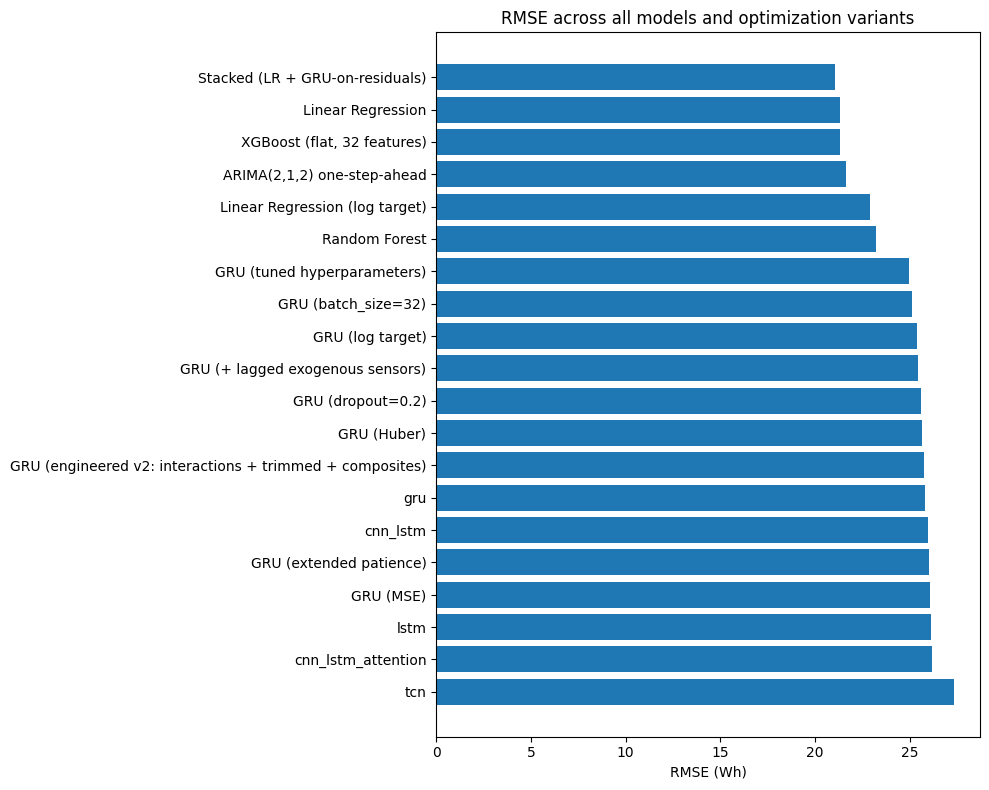

In [27]:
plot_df = updated_master_comparison.sort_values("RMSE", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(plot_df["model"], plot_df["RMSE"])
ax.set_xlabel("RMSE (Wh)")
ax.set_title("RMSE across all models and optimization variants")
plt.tight_layout()
plt.savefig("../reports/figures/16_metrics_comparison.png", dpi=150)
plt.show()

Visually confirms the same split seen throughout: every deep learning variant clusters at RMSE 25-27.3, while Linear Regression, ARIMA, XGBoost, and the Stacked model sit in a distinctly better 21-23.2 band.